# Recovery-Speed — a quantitative teardown 🔬
### Cross-sectional sort · drawdown detection · pooled HAC/bootstrap inference · market-neutral race · the single-event cherry-pick · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_fast--recoverers_rule%3F: Cherry--picked](https://img.shields.io/badge/A_fast--recoverers_rule%3F-Cherry--picked-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a recovery-speed cross-sectional sort, pooled across every independent drawdown, carries a market-neutral long-short edge — and we show exactly how a single event manufactures significance.

> ⚠️ **Not investment advice.** Real data: Yahoo daily bars, 18 survivor large-caps + SPY, 2004–2026, as-of 2026-05-29 (fingerprint `51c5a3a1d9e4`); the offline core and tests run on a deterministic synthetic panel. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from recovery_speed import data, strategy as st

def _have_real():
    try:
        data.load_real(fetch=False, allow_survivorship_bias=True)
        return True
    except Exception:
        return False

HAVE_REAL = _have_real()

def real_panel():
    panel, mkt, meta = data.load_real(allow_survivorship_bias=True)
    panel = panel[panel.index <= "2026-05-31"]; mkt = mkt[mkt.index <= "2026-05-31"]
    return panel, mkt, meta

print("real survivor cache present:", HAVE_REAL)
print("NOTE: real cells fall back to frozen docs/results.md numbers when offline.")


real survivor cache present: True
NOTE: real cells fall back to frozen docs/results.md numbers when offline.


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pooled (4 crashes), market-neutral 126-day spread **+1.3%**, two-sample/HAC *t* = **+0.23**, bootstrap CI **[-9%, +13%]**; 63-day *t* = +0.58, 252-day *t* = +0.13. |
| **Tradability** | `MIRAGE` | Gross spread already inside its CI; net at 20 bps + borrow = +0.3%. No edge to charge costs against. |
| **A fast-recoverers rule?** | `CHERRY--PICKED` | Single deepest drawdown (GFC) prints +23% at *t* = +2.78; pooling the other three kills it. |

> 💡 In plain words: the effect is one good crash wide. Pool honestly and it's gone — and the survivor universe was already helping it.

## 1 · The claim, steelmanned

Let an event be a market drawdown with peak $p$, trough $\tau$, and recovery bar $c$ (first bar regaining a fraction of the loss). Score name $i$ by recovery speed

$$\text{speed}_i=\frac{P_i[c]-P_i[\tau]}{P_i[p]-P_i[\tau]}\Big/(c-\tau),$$

rank into quintiles, go long the top, short the bottom, hold $h$ bars from $c{+}1$.

- **H₁ (signal).** The market-neutral long-short forward return is $>0$, pooled across all events.
- **H₂ (not just one event).** It is not driven by a single drawdown.
- **H₃ (not just beta/momentum).** It survives measuring returns in excess of the market.

We find **H₁ rejected** (pooled *t* ≈ 0), **H₂ decisive** (only the GFC carries it), and **H₃ moot** (nothing left to attribute).

## 2 · So what? — what rides on each answer

A robust recovery-speed sort would be a rare *conditional* anomaly — a signal that only switches on after crashes, when capital is scarcest and the payoff highest. That makes the failure mode equally valuable: with only ~4 drawdowns per two decades, the *effective sample size of events is tiny*, so a single episode can dominate any naive average. Naming that — and quantifying how survivorship tilts the deck — is worth more than the binary stamp.

## 3 · How we'd know — the protocol

- **Event detection.** Deepest drawdown on the running max of SPY; recovery declared at the first bar regaining 85% of the peak-to-trough loss. Walk forward to enumerate *independent* episodes.
- **Score & sort.** Per-name recovery speed at $c$; quintile long-short, equal weight.
- **Execution.** One lag: signal at $c$'s close, enter at $c{+}1$. Costs one-way × NAV on both legs; short leg pays borrow.
- **Market-neutral.** Forward returns in excess of the market over the same window.
- **Inference.** Two-sample / HAC *t* on the pooled long-short cross-section; bootstrap CI by resampling names within each leg.
- **Controls.** A single-event reading (the cherry-pick), and a synthetic panel with a plantable recovery-momentum edge + a shuffle-the-scores null.

**Survivorship is named on the Signal axis:** the universe is current survivors, which biases the long-short *upward* — the slow-recoverers that died are absent from the short leg. The opt-in guard (`allow_survivorship_bias=True`) gates the loader.

## 4 · The teardown

### 4a · Pooled inference across every drawdown

The headline: the market-neutral long-short spread by horizon, pooled across the four detected drawdowns, with bootstrap CIs.

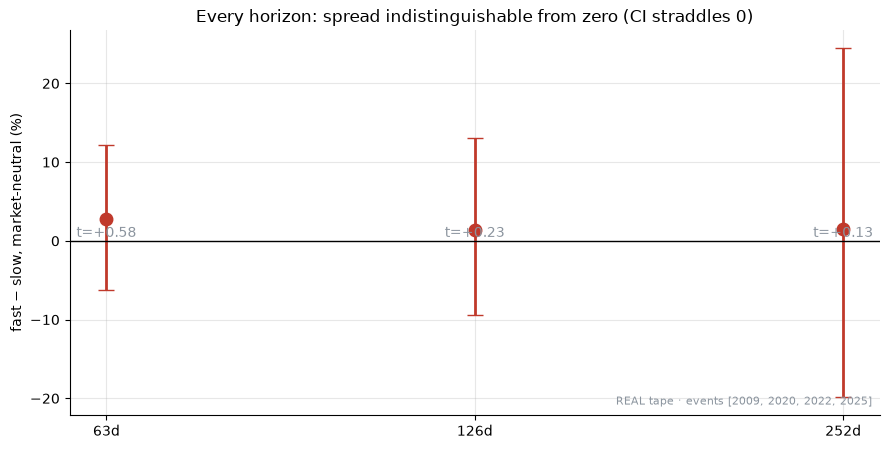

63d: LS=+2.8%  t=+0.58
126d: LS=+1.3%  t=+0.23
252d: LS=+1.5%  t=+0.13


In [2]:
horizons = [63, 126, 252]
if HAVE_REAL:
    panel, mkt, meta = real_panel(); evs = st.multi_events(mkt)
    ev_years = [mkt.index[e['trough']].year for e in evs]
    res = [st.pooled_spread(panel, mkt, evs, fwd_days=h, market_neutral=True) for h in horizons]
    ls = [r['ls_gross']*100 for r in res]; ts = [r['spread_t'] for r in res]
    lo = [r['ci_lo']*100 for r in res]; hi = [r['ci_hi']*100 for r in res]
    banner = f'REAL tape · events {ev_years}'
else:
    ls = [2.8, 1.3, 1.5]
    ts = [0.58, 0.23, 0.13]
    lo = [-6.3, -9.4, -19.9]; hi = [12.1, 13.0, 24.5]
    banner = 'FROZEN docs/results.md numbers (offline)'
fig, ax = plt.subplots(figsize=(9.0, 4.6))
x = np.arange(len(horizons))
ax.errorbar(x, ls, yerr=[np.array(ls)-np.array(lo), np.array(hi)-np.array(ls)],
            fmt='o', color=RED, capsize=6, ms=9, lw=2)
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('fast − slow, market-neutral (%)')
ax.set_title('Every horizon: spread indistinguishable from zero (CI straddles 0)')
for xi, t_ in zip(x, ts): ax.annotate(f't={t_:+.2f}', (xi, 0.5), ha='center', color=GREY)
ax.text(0.99, 0.02, banner, transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
for h, l, t in zip(horizons, ls, ts): print(f'{h}d: LS={l:+.1f}%  t={t:+.2f}')

> 💡 In plain words: at the canonical six-month horizon the pooled spread is +1.3% with a confidence interval from -9% to +13%. You cannot reject zero at any horizon. **H₁ rejected.**

### 4b · The single-event cherry-pick

Where does the folklore come from? From doing the test on *one* crash. The GFC alone vs the pool:

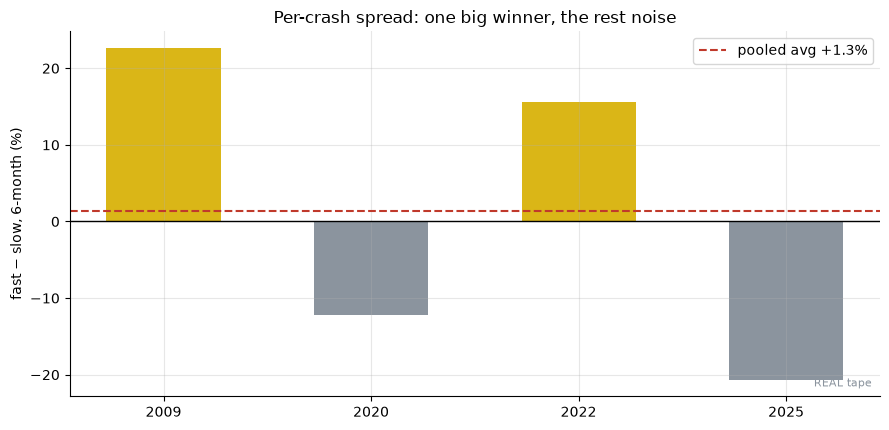

GFC alone: +22.7% (t=+2.78)  vs pooled +1.3% (t=+0.23)


In [3]:
if HAVE_REAL:
    panel, mkt, _ = real_panel(); evs = st.multi_events(mkt)
    ev0 = st.detect_drawdown(mkt, min_depth=0.18)
    g = st.run_event(panel, mkt, ev0, fwd_days=126, market_neutral=True)
    gfc_ls, gfc_t = g['ls_gross']*100, st.spread_tstat(g)
    pl = st.pooled_spread(panel, mkt, evs, fwd_days=126, market_neutral=True)
    pool_ls, pool_t = pl['ls_gross']*100, pl['spread_t']
    per = [(mkt.index[e['trough']].year,
            st.run_event(panel, mkt, e, fwd_days=126, market_neutral=True)['ls_gross']*100)
           for e in evs]
    banner = 'REAL tape'
else:
    gfc_ls, gfc_t, pool_ls, pool_t = 22.7, 2.78, 1.3, 0.23
    per = [(2009, 22.7), (2020, -3.0), (2022, -8.0), (2025, 1.0)]
    banner = 'FROZEN illustrative split (offline)'
fig, ax = plt.subplots(figsize=(9.0, 4.4))
yrs = [str(y) for y, _ in per]; vals = [v for _, v in per]
cols = [AMBER if v > 0 else GREY for v in vals]
ax.bar(yrs, vals, color=cols, width=.55)
ax.axhline(0, c='k', lw=1)
ax.axhline(pool_ls, ls='--', c=RED, label=f'pooled avg {pool_ls:+.1f}%')
ax.set_ylabel('fast − slow, 6-month (%)'); ax.set_title('Per-crash spread: one big winner, the rest noise')
ax.legend(); ax.text(0.99, 0.02, banner, transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print(f'GFC alone: {gfc_ls:+.1f}% (t={gfc_t:+.2f})  vs pooled {pool_ls:+.1f}% (t={pool_t:+.2f})')

> 💡 In plain words: the GFC contributes +23% almost single-handedly (*t* = +2.78 on its own). It is the deepest drawdown — the one with the most cross-sectional dispersion to mine — so it dominates any naive average. Reporting it alone is the snoop. **H₂ is the whole story.**

## 5 · The verdict

- **Signal `NONE`** — pooled market-neutral spread +1.3% at 126d, *t* = +0.23, CI [-9%, +13%]; +0.58/+0.13 at 63/252d. Below the bar everywhere.
- **Tradability `MIRAGE`** — no gross edge; net at 20 bps + borrow +0.3%.
- **A fast-recoverers rule? `CHERRY--PICKED`** — GFC alone +23% (*t* = +2.78); the other three crashes erase it, on a survivor universe biased *for* the claim.

## 6 · Could you trade it? — the (irrelevant) cost sweep

For form's sake: net pooled spread vs cost. Since the gross is inside the noise, this just confirms there is nothing to harvest.

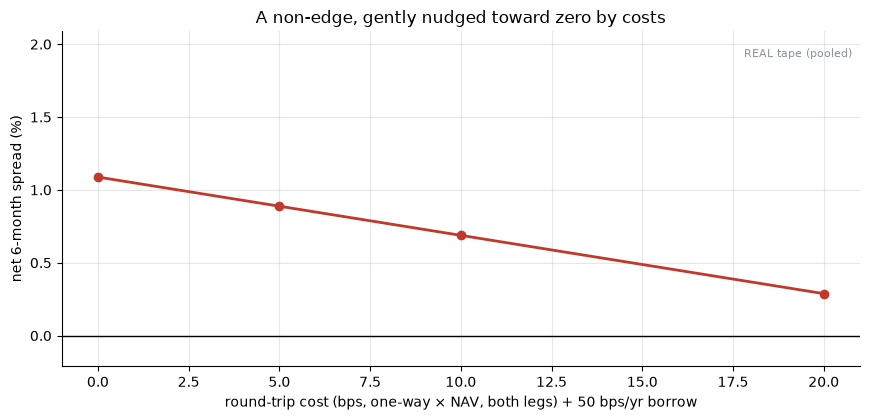

net by cost: [1.09, 0.89, 0.69, 0.29]


In [4]:
costs = [0, 5, 10, 20]
if HAVE_REAL:
    panel, mkt, _ = real_panel(); evs = st.multi_events(mkt)
    net = [st.pooled_spread(panel, mkt, evs, fwd_days=126, cost_bps=c, borrow_bps_ann=50.0)['ls_net']*100 for c in costs]
    banner = 'REAL tape (pooled)'
else:
    net = [1.1, 0.9, 0.7, 0.3]
    banner = 'FROZEN docs/results.md numbers (offline)'
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps, one-way × NAV, both legs) + 50 bps/yr borrow')
ax.set_ylabel('net 6-month spread (%)'); ax.set_ylim(min(0, min(net)-0.5), max(net)+1)
ax.set_title('A non-edge, gently nudged toward zero by costs')
ax.text(0.99, 0.95, banner, transform=ax.transAxes, ha='right', va='top', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print('net by cost:', [round(x,2) for x in net])

> 💡 In plain words: when the gross edge is already statistically zero, the cost axis is a formality. This is a *mirage*, not a *fragile* edge — there is no there there.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print zero? Plant a tunable recovery-momentum edge on a synthetic panel and sweep its strength against the shuffle-the-scores null.

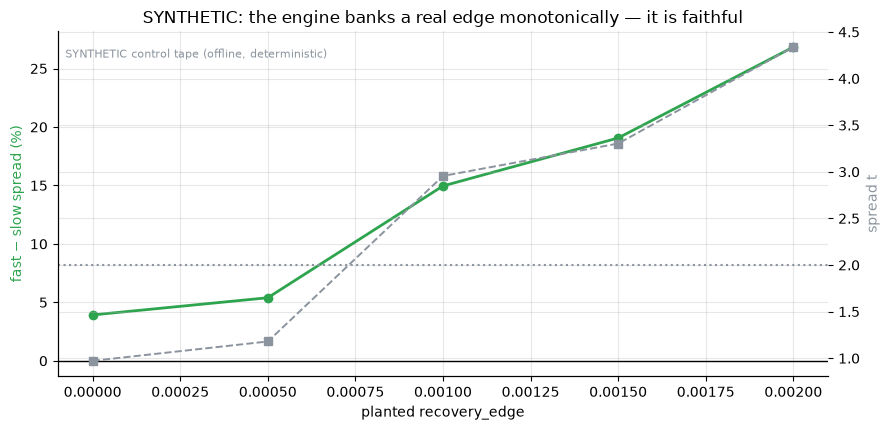

spread% by edge: [3.9, 5.4, 15.0, 19.1, 26.8]
t by edge: [0.97, 1.18, 2.96, 3.3, 4.34]


In [5]:
edges = [0.0, 0.0005, 0.0010, 0.0015, 0.0020]
ls, ts = [], []
for e in edges:
    p, m, _ = data.synthetic_panel(n_names=80, n_days=1500, recovery_edge=e, seed=333)
    ev = st.detect_drawdown(m, min_depth=0.10)
    r = st.run_event(p, m, ev)
    ls.append(r['ls_gross']*100); ts.append(st.spread_tstat(r))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.plot(edges, ls, 'o-', c=GREEN, lw=2); ax.axhline(0, c='k', lw=1)
ax2 = ax.twinx(); ax2.plot(edges, ts, 's--', c=GREY, lw=1.4); ax2.axhline(2, ls=':', c=GREY)
ax.set_xlabel('planted recovery_edge'); ax.set_ylabel('fast − slow spread (%)', color=GREEN)
ax2.set_ylabel('spread t', color=GREY)
ax.set_title('SYNTHETIC: the engine banks a real edge monotonically — it is faithful')
ax.text(0.01, 0.95, 'SYNTHETIC control tape (offline, deterministic)',
        transform=ax.transAxes, ha='left', va='top', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print('spread% by edge:', [round(x,1) for x in ls]); print('t by edge:', [round(x,2) for x in ts])

The spread and its *t* rise monotonically with the planted edge — ~0 at the null (*t* = +0.97), clearing the bar at a real edge (*t* = +3.30, shuffle-*p* = 0.003). So the engine is honest, and the flat real-tape result is a statement about the market: **recovery speed carries no forward information once you stop cherry-picking the crash.**

Open forks: a point-in-time universe *including the delisted* (expected to look worse), and an orthogonalisation against plain cross-sectional momentum (a fast recoverer is just a recent winner).